# I - ETAPA: TRATAMENTO DE DADOS

In [89]:
# Bibliotecas que serão utilizadas no tratamento dos dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1ª Base de dados "palavritas_sessions.csv"

In [33]:
# Carregar os dados do arquivo CSV para um DataFrame do pandas
sessao = pd.read_csv('base_dados/palavritas_sessions.csv', sep=',')

# Exibir as primeiras linhas do DataFrame para verificar os dados carregados
sessao.head()

,session_id,user_id,word,word_date,attempts,result,time_to_complete_sec,device,session_hour,streak_day,played_next_day,newsletter_open_before_game,active_d30
0,ab38635a07ede4246661,697e9e150e91bb76,TEMPO,2026-02-08,1,win,449,Android,20,2,False,False,False
1,67d40a22cba1a16fd2c5,d7f63dda905adaec,FALHA,2026-05-08,6,lose,232,ios,19,1,True,False,False
2,3635c5707f62ea022423,6220de621fef79b8,FALHA,2026-04-18,3,win,65,iOS,7,2,False,False,False
3,27243d4c7b1669f71ba7,3aa2f6a86d7fe06c,PRATO,2025-12-22,6,lose,404,Android,23,2,False,False,True
4,cd21162dd072f066c160,97af736a7f2aa637,IDEIA,2026-05-28,1,win,222,Android,6,2,False,True,False


**Atribuições das variáveis:** \
session_id = Identificador único da sessão de jogo; \
user_id = Identificador anonimizado do usuário; \
word = Palavra do desafio do dia; \
word_date = Data do desafio; \
attempts = Número de tentativas (1–6); \
result = Resultado: win / lose; \
time_to_complete_sec = Tempo de jogo em segundos; \
device = Dispositivo usado; \
session_hour = Hora do dia em que jogou (0–23); \
streak_day = Dia atual da sequência do usuário; \
played_next_day = Se o usuário voltou a jogar no dia seguinte; \
newsletter_open_before_game = Se abriu a newsletter antes de jogar naquele dia; \
active_d30 = Se o usuário estava ativo 30 dias após essa sessão.

### A) Análise dos tipos de dados, se possuem dados faltantes e a quantidade

In [10]:
# Exibir informações sobre o DataFrame, incluindo tipos de dados e contagem de valores não nulos
sessao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   session_id                   41157 non-null  object
 1   user_id                      41157 non-null  object
 2   word                         41157 non-null  object
 3   word_date                    41157 non-null  object
 4   attempts                     41157 non-null  int64 
 5   result                       41094 non-null  object
 6   time_to_complete_sec         41157 non-null  int64 
 7   device                       41157 non-null  object
 8   session_hour                 41157 non-null  int64 
 9   streak_day                   41157 non-null  int64 
 10  played_next_day              41157 non-null  bool  
 11  newsletter_open_before_game  41157 non-null  bool  
 12  active_d30                   41157 non-null  bool  
dtypes: bool(3), int64(4), object(6)

**Análise:** \
A variável "word_date" trata de datas, e está em formato object, logo, necessitara de maior análise para posterior correção. O restante das variáveis apresentam o formato dos dados compativeis com suas atribuições. Vale observar que apenas a variável "result" apresenta valores nulos, o que resultara em uma posterior análise e tratamento.

#### Análise, tratamento e conversão da variável "word_data" para o tipo data

In [15]:
# Conferência dos dados preenchidos da variável "word_date"
sessao['word_date'].unique()

array(['2026-02-08', '2026-05-08', '2026-04-18', '2025-12-22',
       '2026-05-28', '2026-05-25', '2026-03-01', '2025-12-29',
       '19/01/2026', '2026-01-25', '2026-01-14', '2026-02-09',
       '2026-01-12', '2026-01-21', '2026-04-10', '2026-01-23',
       '2025-12-09', '2026-04-01', '13/02/2026', '2026-05-29',
       '2026-03-06', '2026-01-17', '2026-05-11', '2025-12-03',
       '2025-12-24', '2025-12-31', '2026-01-09', '2025-12-10',
       '2026-04-09', '2026-04-06', '2026-02-17', '2026-04-16',
       '2026-01-13', '2026-05-22', '20/01/2026', '2026-02-07',
       '2025-12-17', '2026-04-08', '2026-03-03', '2026-05-07',
       '2026-03-22', '2026-02-21', '07/05/2026', '2026-02-16',
       '2026-05-12', '2026-03-30', '26/03/2026', '2026-03-19',
       '2026-04-30', '2026-04-03', '2026-04-22', '22/05/2026',
       '2026-04-05', '2025-12-23', '2026-02-01', '2026-05-16',
       '2026-02-12', '2026-01-20', '2026-02-04', '2026-05-03',
       '2026-04-07', '20/03/2026', '05/05/2026', '2026-

**Análise:** \
Ao analisar detalhadamente a variável, foi identificado que um dos fatores que impede seu reconhecimento como uma data é a presença de registros em formatos diferentes. Parte dos valores está no padrão brasileiro (DD/MM/AAAA), utilizando barras (/), enquanto outra parte está no padrão ISO (AAAA-MM-DD), utilizando hífens (-). Essa inconsistência impossibilita a correta conversão da coluna para o tipo datetime.

Antes de realizar a conversão, será efetuada a remoção de possíveis espaços em branco no início e no final dos registros, evitando falhas durante o processo de transformação. Em seguida, todos os valores serão convertidos para o tipo datetime, padronizando a variável e permitindo sua utilização nas análises temporais da etapa de EDA.

In [34]:
# Remoção de espaços em branco (prevenção caso haja) no início e no final da variável "word_date"
sessao['word_date'] = sessao['word_date'].astype(str).str.strip()

# Conversão para datetime
sessao['word_date'] = pd.to_datetime(
    sessao['word_date'], 
    format='mixed',
    errors='coerce'  # Isso irá converter valores inválidos para NaT (Not a Time)
)

In [22]:
# Conferência dos dados preenchidos da variável "word_date" após a conversão
sessao['word_date'].unique()

<DatetimeArray>
['2026-02-08 00:00:00', '2026-05-08 00:00:00', '2026-04-18 00:00:00',
 '2025-12-22 00:00:00', '2026-05-28 00:00:00', '2026-05-25 00:00:00',
 '2026-03-01 00:00:00', '2025-12-29 00:00:00', '2026-01-19 00:00:00',
 '2026-01-25 00:00:00',
 ...
 '2026-07-01 00:00:00', '2025-06-12 00:00:00', '2026-11-05 00:00:00',
 '2025-05-12 00:00:00', '2026-08-05 00:00:00', '2026-09-03 00:00:00',
 '2026-10-04 00:00:00', '2026-12-05 00:00:00', '2026-11-03 00:00:00',
 '2026-10-01 00:00:00']
Length: 226, dtype: datetime64[ns]

**Análise:** \
Após a conversão, a variável passou a exibir também o horário (00:00:00). Como a base de dados não contém informações de hora vinculado a data, esse componente não possui relevância para as análises. Ainda assim, ele será mantido, pois faz parte do tipo datetime do pandas e garante maior flexibilidade para manipulações e análises temporais futuras.

In [ ]:
# Conferência do formato da variável "word_date" após a conversão
sessao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   session_id                   41157 non-null  object        
 1   user_id                      41157 non-null  object        
 2   word                         41157 non-null  object        
 3   word_date                    41157 non-null  datetime64[ns]
 4   attempts                     41157 non-null  int64         
 5   result                       41094 non-null  object        
 6   time_to_complete_sec         41157 non-null  int64         
 7   device                       41157 non-null  object        
 8   session_hour                 41157 non-null  int64         
 9   streak_day                   41157 non-null  int64         
 10  played_next_day              41157 non-null  bool          
 11  newsletter_open_before_game  41157 non-nu

#### Análise e tratamento de valores nulos da variável "result"

In [48]:
# Conferência da quantidade de dados nulos da variável "result"
quantidade_nulos = sessao['result'].isnull().sum()

print(f'Quantidade de valores nulos da variável "result": {quantidade_nulos}')

Quantidade de valores nulos da variável "result": 63


In [49]:
# Conferência do percentual de dados nulos da variável "result"
percentual_nulos = sessao['result'].isnull().mean() * 100

print(f'Percentual de valores nulos da variável "result": {percentual_nulos:.2f}%')

Percentual de valores nulos da variável "result": 0.15%


**Análise:** \
A variável possui cerca de 0,15% de valores nulos. Devido à baixa ocorrência desses registros, eles serão removidos, pois seu impacto sobre a base de dados é considerado desprezível.

In [50]:
# Exclusão de linhas com valores nulos na variável "result"
sessao = sessao.dropna(subset=['result'])

In [51]:
# Conferência dos valores nulos após a exclusão
sessao.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41094 entries, 0 to 41156
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   session_id                   41094 non-null  object        
 1   user_id                      41094 non-null  object        
 2   word                         41094 non-null  object        
 3   word_date                    41094 non-null  datetime64[ns]
 4   attempts                     41094 non-null  int64         
 5   result                       41094 non-null  object        
 6   time_to_complete_sec         41094 non-null  int64         
 7   device                       41094 non-null  object        
 8   session_hour                 41094 non-null  int64         
 9   streak_day                   41094 non-null  int64         
 10  played_next_day              41094 non-null  bool          
 11  newsletter_open_before_game  41094 non-null  b

### B) Análise e padronização do preenchimento das variáveis

A análise de preenchimento será realizada apenas nas variáveis do tipo object, desconsiderando as colunas que atuam como identificadores. As variáveis dos tipos data, int e bool também não serão analisadas, pois já se encontram padronizadas, armazenadas no tipo de dado adequado e não apresentam necessidade de avaliação quanto ao preenchimento nesta etapa.

In [82]:
# Variáveis que serão analisadas "word", "result" e "device"
a1 = sessao['word'].unique()
a2 = sessao['result'].unique()
a3 = sessao['device'].unique()

print(f'Valores únicos da variável "word":\n {a1}\n')
print(f'Valores únicos da variável "result":\n {a2}\n')
print(f'Valores únicos da variável "device":\n {a3}\n')

Valores únicos da variável "word":
 ['TEMPO' 'FALHA' 'PRATO' 'IDEIA' 'NUVEM' 'DANÇA' 'BARCO' 'PLANO' 'CORVO'
 'TROCO' 'GENRO' 'METAL' 'VINHO' 'HERÓI' 'PRETO' 'VENTO' 'MORRO' 'FRACO'
 'NIXÃO' 'CIÚME' 'PAZÃO' 'JOGOS' 'CAMPO' 'FILME' 'CASCA' 'PRAIA' 'SONHO'
 'LARGO' 'ORAÇÃ' 'ROSTO']

Valores únicos da variável "result":
 ['win' 'lose']

Valores únicos da variável "device":
 ['Android' 'ios' 'iOS' 'android' 'IOS' 'ANDROID']



**Análise:** \
Foi identificado que a variável "device" apresenta categorias iguais registradas com diferenças nas letras, com maiúsculas e minúsculas, fazendo com que o mesmo dispositivo seja interpretado como categorias distintas. Para garantir a consistência dos dados e evitar duplicidade de categorias durante as análises, será realizada a padronização dos valores.

Além disso, observou-se que a variável "result" possui seus registros preenchidos em letras minúsculas, diferindo do padrão adotado nas demais variáveis categóricas. Assim, seus valores também serão padronizados, visando manter a uniformidade e a legibilidade da base de dados.

In [85]:
# Correção dos valores da variável "result" para padronização
sessao['result'] = sessao['result'].replace({
    'win': 'Win',
    'lose': 'Lose',
})

# Correção das categorias da variável "device" para padronização
sessao['device'] = sessao['device'].replace({
    'android': 'Android',
    'ANDROID': 'Android',
    'ios': 'iOS',
    'IOS': 'iOS',
})

In [86]:
# Verificação da padronização dos valores das variáveis "result" e "device"
a1 = sessao['result'].unique()
a2 = sessao['device'].unique()

print(f'Valores únicos da variável "result":\n {a1}\n')
print(f'Valores únicos da variável "device":\n {a2}\n')

Valores únicos da variável "result":
 ['Win' 'Lose']

Valores únicos da variável "device":
 ['Android' 'iOS']



### C) Análise mais precisa de valores nulos, faltantes e outliers (valores discrepantes)

In [87]:
# Verificação de valores nulos e faltantes
sessao.isnull().sum()

session_id                     0
user_id                        0
word                           0
word_date                      0
attempts                       0
result                         0
time_to_complete_sec           0
device                         0
session_hour                   0
streak_day                     0
played_next_day                0
newsletter_open_before_game    0
active_d30                     0
dtype: int64

In [88]:
# Verificação de outliers (valores discrepantes)
sessao.describe()

,word_date,attempts,time_to_complete_sec,session_hour,streak_day
count,41094,41094.000000,41094.000000,41094.000000,41094.000000
mean,2026-03-03 21:09:46.070959360,3.583735,269.831411,15.147783,1.292378
min,2025-01-12 00:00:00,0.000000,60.000000,6.000000,1.000000
25%,2026-01-15 00:00:00,2.000000,164.000000,8.000000,1.000000
50%,2026-03-02 00:00:00,3.000000,269.000000,17.000000,1.000000
75%,2026-04-19 00:00:00,6.000000,375.000000,21.000000,1.000000
max,2026-12-05 00:00:00,8.000000,480.000000,23.000000,8.000000
std,NaN,2.063170,121.808822,6.213868,0.631086


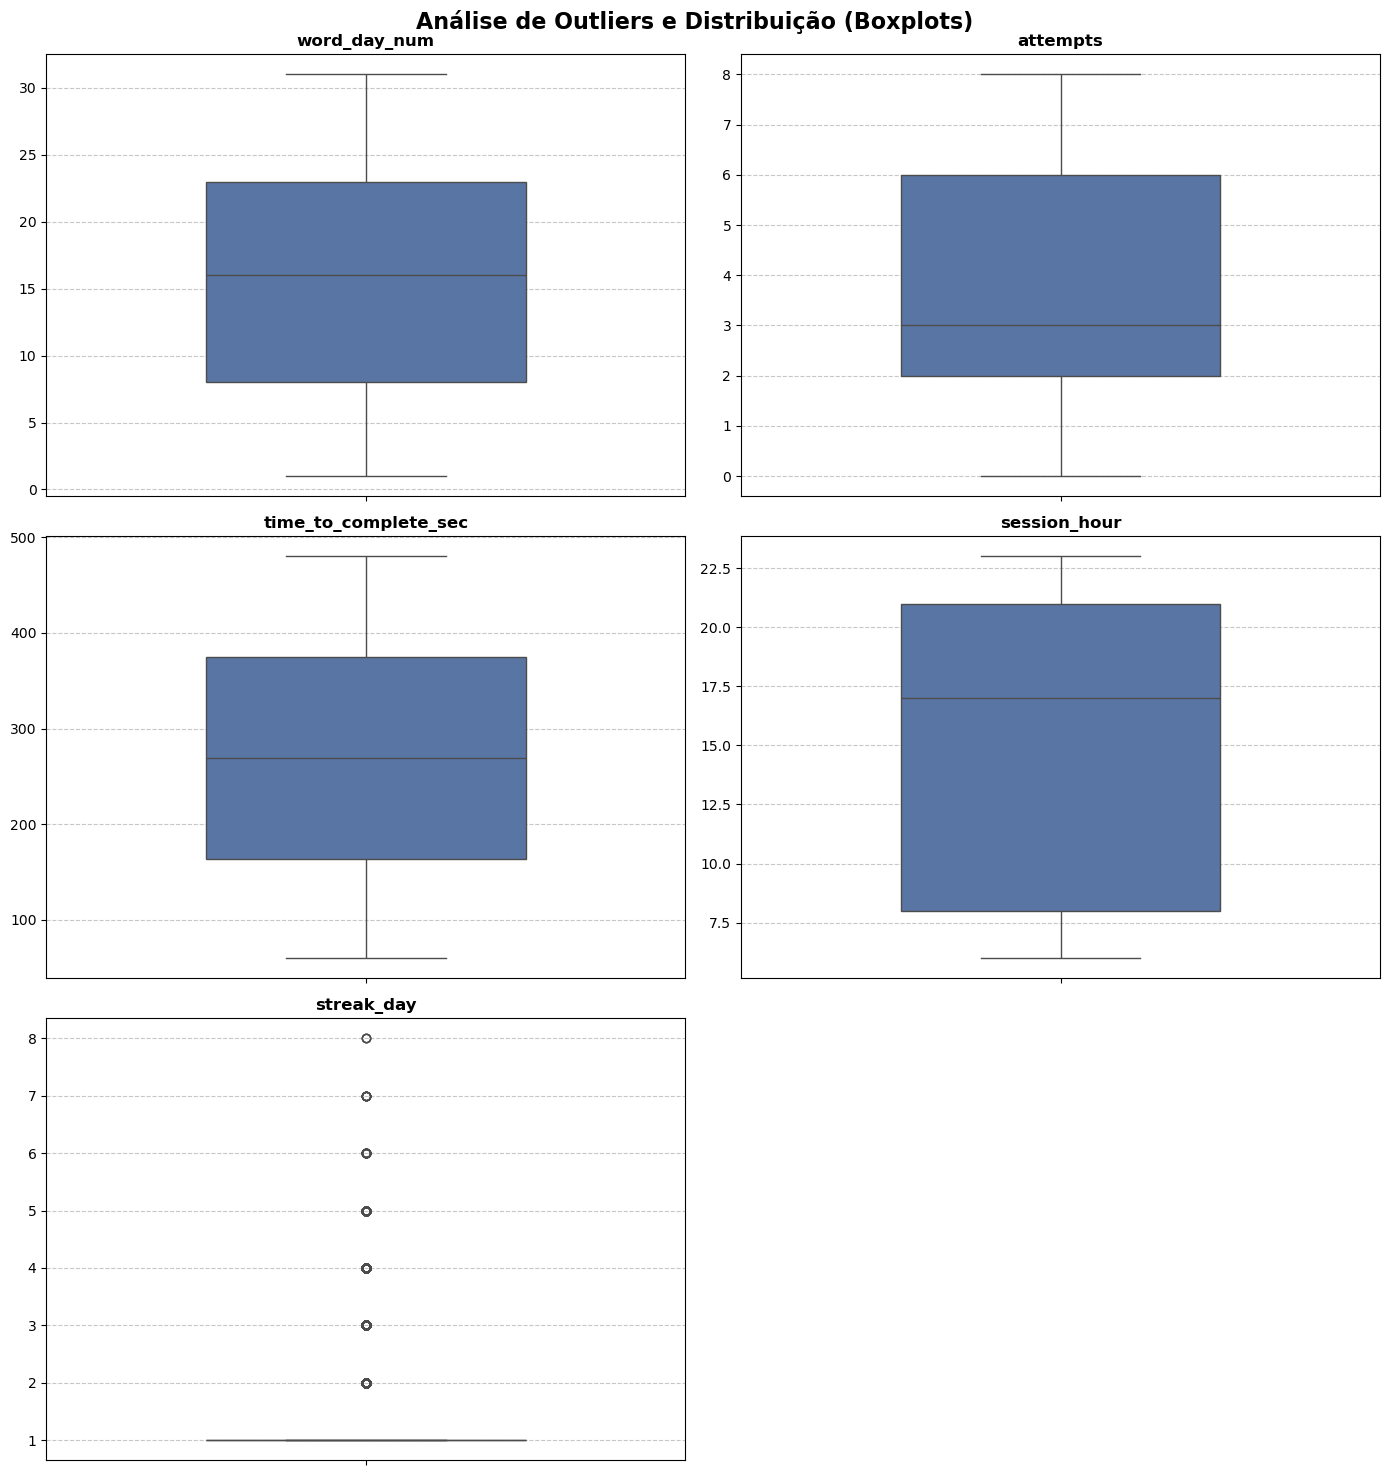

In [ ]:
# Boxplot para análise de outliers e distribuição das variáveis numéricas
# Extrair o dia da coluna "word_date"
sessao['word_day_num'] = sessao['word_date'].dt.day  # Extrai o dia do mês (1 a 31)

# Lista com as colunas numéricas para o Boxplot
colunas_analise = ['word_day_num', 'attempts', 'time_to_complete_sec', 'session_hour', 'streak_day']

# Configurar a estrutura dos gráficos (3 linhas com 2 colunas)
# Dica: Aumentei o figsize para 15 de altura para os 3 blocos não ficarem esmagados
fig, axes = plt.subplots(3, 2, figsize=(14, 15)) 
fig.suptitle('Análise de Outliers e Distribuição (Boxplots)', fontsize=16, fontweight='bold')

# .flatten() transforma a matriz 3x2 em uma lista linear de 6 posições
axes_flat = axes.flatten()

# Gerar Boxplot para cada coluna
for i, col in enumerate(colunas_analise):
    sns.boxplot(y=sessao[col], ax=axes_flat[i], color='#4C72B0', width=0.5)
    axes_flat[i].set_title(col, fontsize=12, fontweight='bold')
    axes_flat[i].set_ylabel('')  # Limpa o eixo Y
    axes_flat[i].grid(axis='y', linestyle='--', alpha=0.7)

# Como temos 5 gráficos para 6 espaços, removemos o último quadrante vazio
fig.delaxes(axes_flat[-1])

# Ajusta o espaçamento para não cortar nada
plt.tight_layout()
plt.show()


**Análise:** \
Após a conclusão do tratamento dos dados, constatou-se que a base não possui mais valores nulos ou ausentes. A análise dos valores extremos, realizada por meio de boxplots, também não identificou outliers que justificassem intervenção, indicando que a base está consistente e preparada para as etapas seguintes de finalização de tratamento e posterior análise exploratoria de dados.